In [1]:
import fuse
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

2025-12-16 12:34:41,265 - utilix - WARNING - Could not load a configuration file. You can create one at /home/l-althueser/.xenon_config, or set a custom path using

export XENON_CONFIG=path/to/your/config



## Make simulations

10.12.2025 - gamma simulations ER background
```
cd /mnt/c/L_Althueser/git/HermeticTPC
. make.sh
./build/bin/hermeticTPC -f macros/run_Sapphire_U238.mac -o 20251210_Sapphire_U238_100k_gamma.root -n 100000
```

05.12.2025 - neutron simulations NR background
```
cd /mnt/c/L_Althueser/git/HermeticTPC
. make.sh
./build/bin/hermeticTPC -f macros/run_Sapphire_U238_neutrons.mac -o 20251205_Sapphire_U238_1k_neutrons.root -n 1000
```

## Clustering with fuse

In [2]:
st = fuse.context.public_config_context(output_folder="./fuse_data", 
                                        simulation_config_file="./fuse_files/XENONnT_public_config.json",
                                        clustering_method="lineage")

st.set_config(
    {
        "path": "../",
        "file_name": "20251210_Sapphire_U238_100k_gamma.root",
        "entry_stop": None,
    }
)

run_number = "00000"

#st.make(run_number, "geant4_interactions")
#st.make(run_number, "interaction_lineage")
#st.make(run_number, "clustered_interactions")

In [3]:
fuse_g4clusters = st.get_df(run_number, ["clustered_interactions"])

Loading ['clustered_interactions']: |          | 0.00 % [00:00<?]

In [5]:
fuse_g4clusters.head()

,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime
0,25.838276,-114.811584,136.491608,120.454773,8,1,8,263,0.0,0,0,18.653528,-100.598839,145.790985,11514639146,11514639146
1,-46.393105,-41.608879,-167.670197,77.406792,8,4,22,79,0.0,0,0,-46.239708,-41.825401,-167.809982,18337372787,18337372787
2,-46.217026,-41.792400,-167.744431,82.835732,8,6,23,4,0.0,0,0,-46.239708,-41.825401,-167.809982,18607172261,18607172261
3,59.064022,9.910222,-145.212494,510.998901,8,11,37,457,0.0,0,0,68.238365,9.669704,-167.822891,24826818528,24826818528
4,71.310585,12.172292,-147.562912,742.509338,8,8,37,287,0.0,0,0,68.238365,9.669704,-167.822891,24826818528,24826818528


## Clustering with own method

```
python analysis/proc_root_reduced.py /mnt/c/L_Althueser/git/HermeticTPC/20251210_Sapphire_U238_100k_gamma.root --outfile /mnt/c/L_Althueser/git/HermeticTPC/20251210_Sapphire_U238_100k_gamma_clustered.parquet
```

In [11]:
!python3 ./proc_root_reduced.py /mnt/c/L_Althueser/git/HermeticTPC/20251210_Sapphire_U238_100k_gamma.root --outfile /mnt/c/L_Althueser/git/HermeticTPC/20251210_Sapphire_U238_100k_gamma_clustered.parquet

100%|███████████████████████████████████████████| 35/35 [03:15<00:00,  5.59s/it]
Saving DataFrame as parquet: /mnt/c/L_Althueser/git/HermeticTPC/20251210_Sapphire_U238_100k_gamma_clustered.parquet


In [4]:
df_clustered  = pd.read_parquet("/mnt/c/L_Althueser/git/HermeticTPC/20251210_Sapphire_U238_100k_gamma_clustered.parquet")

In [6]:
df_clustered.head()

,event,cluster,nclusters,e_gam,xp_pri,yp_pri,zp_pri,edep,xp,yp,zp
0,0,0,1,154.084167,186.535278,-1005.988403,1457.909912,120.454781,258.383270,-1148.116211,1364.915039
1,1,0,1,77.406792,-462.397095,-418.254028,-1678.099854,77.406792,-463.932404,-416.089447,-1676.701660
2,2,0,4,1764.507202,682.383667,96.697044,-1678.228882,746.451782,716.025330,122.047394,-1476.228638
3,2,1,4,1764.507202,682.383667,96.697044,-1678.228882,247.172913,591.158203,94.673218,-1454.913086
4,2,2,4,1764.507202,682.383667,96.697044,-1678.228882,263.825989,590.156128,103.257797,-1449.515015


5it [00:00, 621.25it/s]


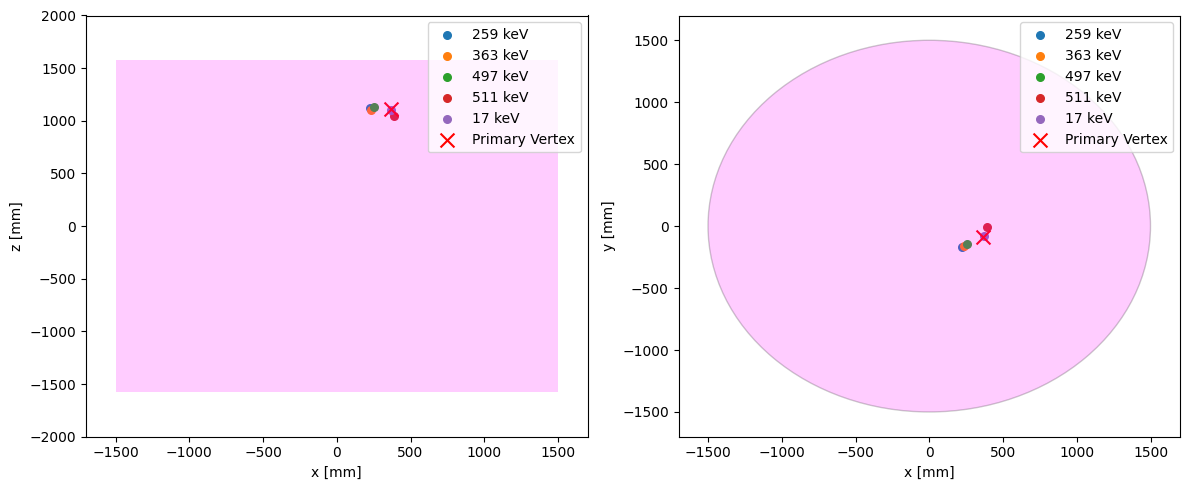

In [57]:
visualise_event(df_clustered[df_clustered['event'] == 6])

3it [00:00, 413.98it/s]

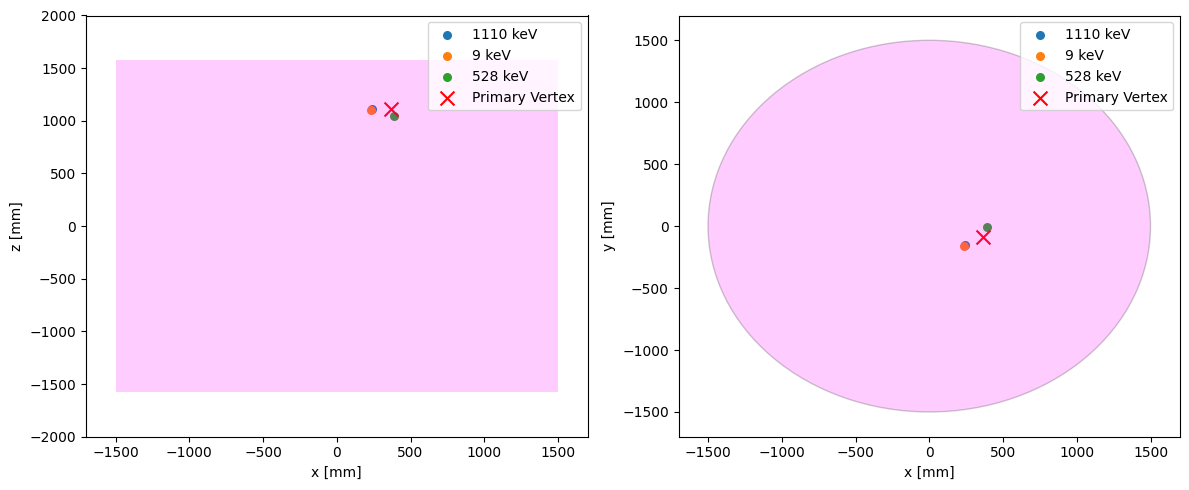

In [61]:
visualise_event(fuse_g4clusters[fuse_g4clusters['eventid'] == 82])

In [62]:
df_clustered[df_clustered['event'] == 6]

,event,cluster,nclusters,e_gam,xp_pri,yp_pri,zp_pri,edep,xp,yp,zp
12,6,0,5,1120.289795,364.440948,-85.251785,1115.310425,259.262970,223.289017,-167.739822,1117.278931
13,6,1,5,1120.289795,364.440948,-85.251785,1115.310425,363.369934,232.929153,-160.638199,1099.659424
14,6,2,5,1120.289795,364.440948,-85.251785,1115.310425,497.656982,254.801559,-140.574631,1127.260254
15,6,3,5,1120.289795,364.440948,-85.251785,1115.310425,511.164062,389.891479,-5.775988,1041.861816
16,6,4,5,1120.289795,364.440948,-85.251785,1115.310425,17.283068,369.694946,-77.066002,1102.383789


In [63]:
fuse_g4clusters[fuse_g4clusters['eventid'] == 82]

,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime
14,24.047369,-15.330060,111.614441,1110.453979,8,33,82,152,0.0,0,0,36.444096,-8.525179,111.531044,51235872434,51235872434
15,23.294527,-16.066477,109.962502,9.835841,8,34,82,408,0.0,0,0,36.444096,-8.525179,111.531044,51235872435,51235872435
16,38.923298,-0.810818,104.384140,528.447144,8,37,82,821,0.0,0,0,36.444096,-8.525179,111.531044,51235872435,51235872435


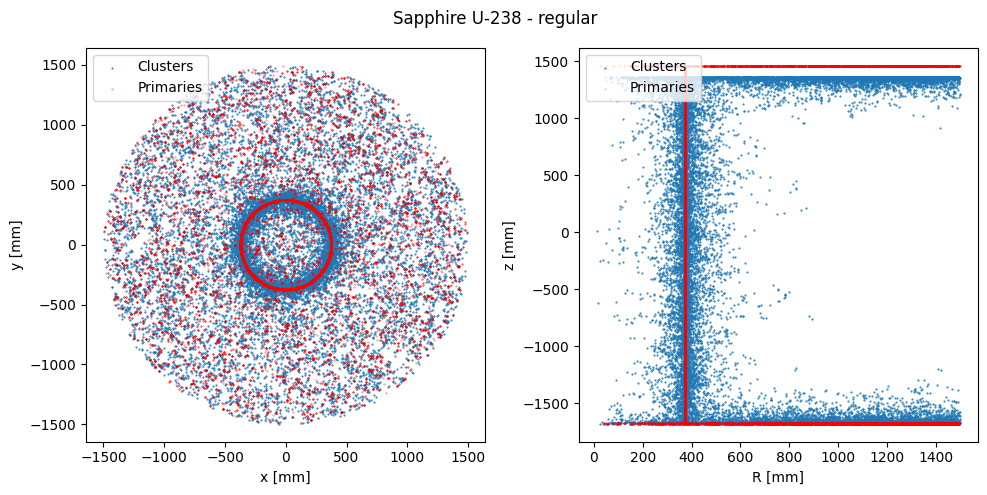

In [91]:
visualise_all_clusters(df_clustered, title="Sapphire U-238 - regular",)

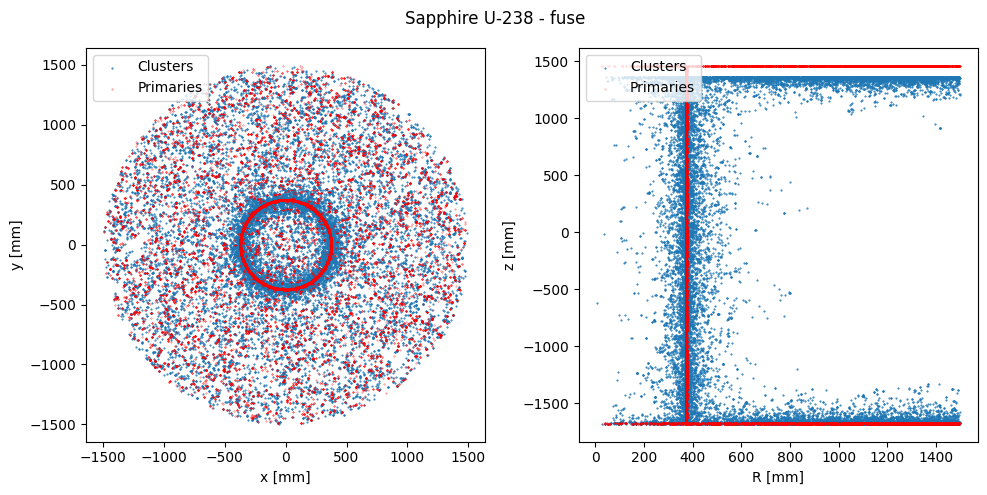

In [92]:
visualise_all_clusters(fuse_g4clusters, title="Sapphire U-238 - fuse",)

In [95]:
fuse_distances  = get_cluster_distances(fuse_g4clusters)
regular_distances  = get_cluster_distances(df_clustered)

100%|██████████| 10544/10544 [00:02<00:00, 4184.22it/s]


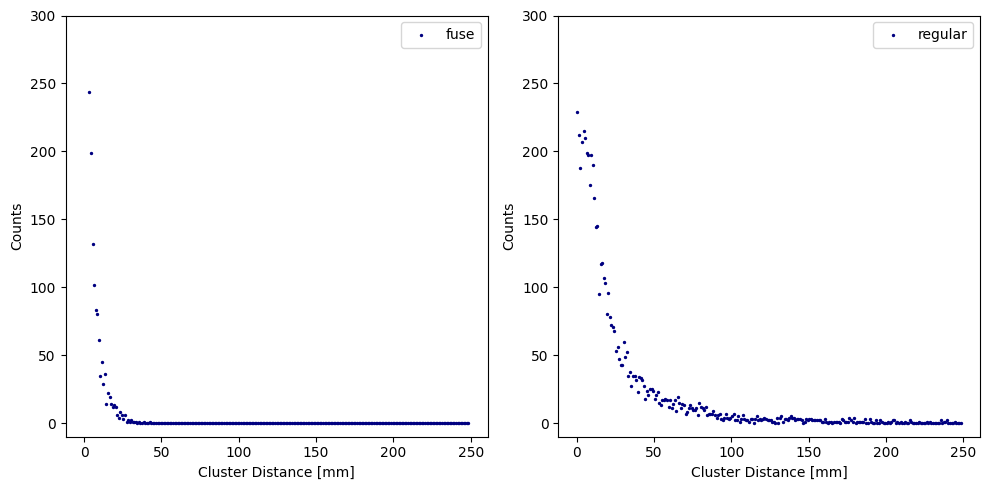

In [98]:
bins = np.arange(0, 250, 1)
bin_mids = 0.5 * (bins[1:] + bins[:-1])
cut = 11

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

hist, bin_edges = np.histogram(fuse_distances, bins=bins)
#popt, _ = curve_fit(exp_decay, bin_mids[cut:], hist[cut:], p0=(1e3, 10))
#meanfree =  popt[1]

ax1.scatter(bin_mids, hist, color='navy', label='fuse', s=2)
#ax1.plot(bin_mids, exp_decay(bin_mids, *popt), color='blue', linestyle='--', label=f'Exp. Fit (MFP={meanfree:.1f} mm)')
ax1.set_xlabel('Cluster Distance [mm]')
ax1.set_ylabel('Counts')
ax1.legend()


hist, bin_edges = np.histogram(regular_distances, bins=bins)
#popt, _ = curve_fit(exp_decay, bin_mids[cut:], hist[cut:], p0=(1e3, 10))
#meanfree =  popt[1]

ax2.scatter(bin_mids, hist, color='navy', label='regular', s=2)
#ax2.plot(bin_mids, exp_decay(bin_mids, *popt), color='blue', linestyle='--', label=f'Exp. Fit (MFP={meanfree:.1f} mm)')
ax2.set_xlabel('Cluster Distance [mm]')
ax2.set_ylabel('Counts')
ax2.legend()

ax1.set_ylim(-10, 300)
ax2.set_ylim(-10, 300)

plt.tight_layout()

In [100]:
fuse_ss, fuse_ms = get_ss_ms_edeps(fuse_g4clusters)
regular_ss, regular_ms = get_ss_ms_edeps(df_clustered)

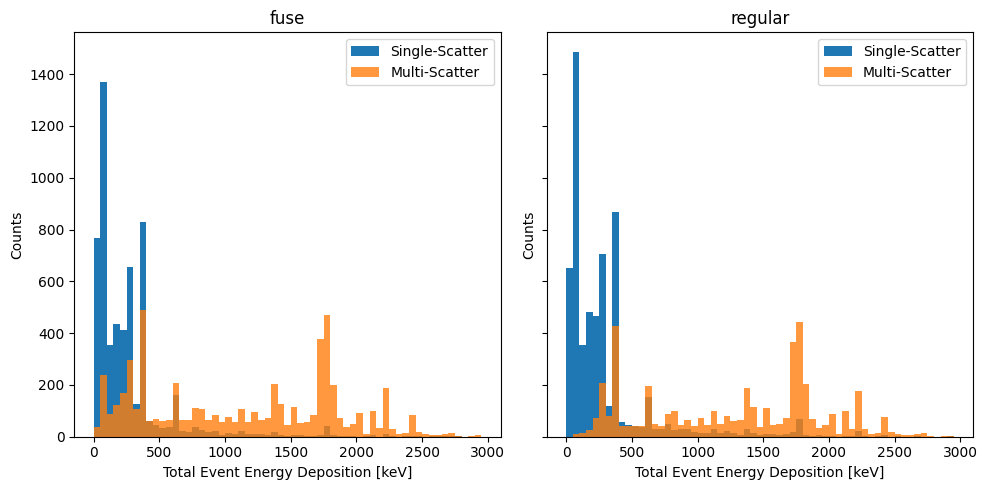

In [101]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharey=True)

alpha = 0.8
bins = np.arange(0, 3000, 50)
ax1.hist(fuse_ss, bins=bins, alpha = 1, label='Single-Scatter')
ax1.hist(fuse_ms, bins=bins, alpha = alpha, label='Multi-Scatter')
ax1.set_xlabel('Total Event Energy Deposition [keV]')
ax1.set_ylabel('Counts')
ax1.legend()
ax1.set_title('fuse')

ax2.hist(regular_ss, bins=bins, alpha = 1, label='Single-Scatter')
ax2.hist(regular_ms, bins=bins, alpha = alpha, label='Multi-Scatter')
ax2.set_xlabel('Total Event Energy Deposition [keV]')
ax2.set_ylabel('Counts')
ax2.legend()    
ax2.set_title('regular')

plt.tight_layout()

In [99]:
def get_unique_events(df):
    if 'event' in df.columns:
        return np.unique(df.loc[:, 'event'].to_numpy())
    else:
        return np.unique(df.loc[:, 'eventid'].to_numpy())

def get_event_df(df, event_num):
    if 'event' in df.columns:
        return df[df['event'] == event_num]
    else: 
        return df[df['eventid'] == event_num]

def get_cluster_distances(df):
    event_ids = get_unique_events(df)
    distances = []
    for id in tqdm(event_ids):
        event_df = get_event_df(df, id)
        if 'zp' in event_df.columns:
            zp = event_df.loc[:, 'zp'].to_numpy()
        else:
            zp = event_df.loc[:, 'z'].to_numpy()
        diffs = np.diff(zp)
        distances.extend(diffs)
    return distances

def get_ss_ms_edeps(df):
    ss_edeps = []
    ms_edeps = []
    events = get_unique_events(df)
    for event in events:
        event_df = get_event_df(df, event)
        if 'edep' in event_df.columns:
            edepp = event_df.loc[:, 'edep'].to_numpy()
        else:
            edepp = event_df.loc[:, 'ed'].to_numpy()
        total_edep = np.sum(edepp)
        if len(edepp) == 1:
            ss_edeps.append(total_edep)
        else:
            ms_edeps.append(total_edep)
            
    return ss_edeps, ms_edeps

In [73]:
def visualise_event(event_df):
    #event_df = get_event_df(df, event_num)

    if isinstance(event_df, pd.Series):
        event_df = pd.DataFrame([event_df])

    if 'xp' in event_df.columns:
        xp_pri = event_df.loc[:, 'xp_pri'].to_numpy()[0]
        yp_pri = event_df.loc[:, 'yp_pri'].to_numpy()[0]
        zp_pri = event_df.loc[:, 'zp_pri'].to_numpy()[0]
        
        xp = event_df.loc[:, 'xp'].to_numpy()
        yp = event_df.loc[:, 'yp'].to_numpy()
        zp = event_df.loc[:, 'zp'].to_numpy()

        edep = event_df.loc[:, 'edep'].to_numpy()
    else:
        xp_pri = event_df.loc[:, 'x_pri'].to_numpy()[0]*10.
        yp_pri = event_df.loc[:, 'y_pri'].to_numpy()[0]*10.
        zp_pri = event_df.loc[:, 'z_pri'].to_numpy()[0]*10.
        
        xp = event_df.loc[:, 'x'].to_numpy()*10.
        yp = event_df.loc[:, 'y'].to_numpy()*10.
        zp = event_df.loc[:, 'z'].to_numpy()*10.

        edep = event_df.loc[:, 'ed'].to_numpy()

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    for cluster, z in tqdm(enumerate(zp)):
        ax1.scatter(xp[cluster], z, s = 30, label = f'{int(edep[cluster])} keV')

    ax1.scatter(xp_pri, zp_pri, c='red', marker='x', s=100, label='Primary Vertex')
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('z [mm]')

    # Box limits
    x_min, x_max = -1500, 1500
    y_min, y_max = -1575, 1575

    # Add shaded rectangle
    rect = Rectangle(
        (x_min, y_min),           # bottom-left corner
        x_max - x_min,            # width
        y_max - y_min,            # height
        facecolor="magenta",         # or any color
        alpha=0.2,
        edgecolor=None
    )
    ax1.add_patch(rect)

    ax1.legend(loc='upper right')
    ax1.set_xlim(-1700, 1700)
    ax1.set_ylim(-2000, 2000)

    for cluster, y in enumerate(yp):
        ax2.scatter(xp[cluster], y, s = 30, label = f'{int(edep[cluster])} keV')

    ax2.scatter(xp_pri, yp_pri, c='red', marker='x', s=100, label='Primary Vertex')
    ax2.set_xlabel('x [mm]')
    ax2.set_ylabel('y [mm]')

    # Circle parameters
    x0, y0 = 0, 0        # center
    r = 1500              # radius

    circle = Circle(
        (x0, y0),        # center
        r,               # radius
        facecolor="magenta",
        alpha=0.2,
        edgecolor="black"   # or None
    )
    ax2.add_patch(circle)

    ax2.legend(loc='upper right')
    ax2.set_xlim(-1700, 1700)
    ax2.set_ylim(-1700, 1700)
    
    plt.tight_layout()
    return None

In [76]:
def visualise_all_clusters(df, title="Cluster Spatial Distribution", show_prim=True, s = 0.25):

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

    if 'xp' in df.columns:
        xp_pri = df.loc[:, 'xp_pri'].to_numpy()
        yp_pri = df.loc[:, 'yp_pri'].to_numpy()
        zp_pri = df.loc[:, 'zp_pri'].to_numpy()
        
        xp = df.loc[:, 'xp'].to_numpy()
        yp = df.loc[:, 'yp'].to_numpy()
        zp = df.loc[:, 'zp'].to_numpy()

        edep = df.loc[:, 'edep'].to_numpy()
    else:
        xp_pri = df.loc[:, 'x_pri'].to_numpy()*10.
        yp_pri = df.loc[:, 'y_pri'].to_numpy()*10.
        zp_pri = df.loc[:, 'z_pri'].to_numpy()*10.
        
        xp = df.loc[:, 'x'].to_numpy()*10.
        yp = df.loc[:, 'y'].to_numpy()*10.
        zp = df.loc[:, 'z'].to_numpy()*10.

        edep = df.loc[:, 'ed'].to_numpy()

    rp =  np.sqrt(xp**2 + yp**2)
    rp_pri =  np.sqrt(xp_pri**2 + yp_pri**2)

    ax1.scatter(xp, yp, s = s, label = 'Clusters')
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')  

    ax2.scatter(rp, zp, s = s, label = 'Clusters')
    ax2.set_xlabel('R [mm]')
    ax2.set_ylabel('z [mm]')

    if show_prim:
        ax1.scatter(xp_pri, yp_pri, c='red', marker='x', s=s*2, alpha=0.3, label = 'Primaries')
        ax2.scatter(rp_pri, zp_pri, c='red', marker='x', s=s*2, alpha=0.2, label = 'Primaries')

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper left')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()